<a href="https://colab.research.google.com/github/braltoids0089/BIOMEDICINE/blob/main/Open_World_Perturbation_Response_Discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Open-World Perturbation Response Discovery**

# **Transferring Unsupervised Cell-Type Discovery Principles to Genetic Perturbation Space**

# A. Introduction and Background
A central challenge in machine learning for biology is **open-world generalisation**: producing meaningful predictions for entities absent during training. The MLBio Lab has addressed this for single-cell transcriptomics through MARS (novel cell-type discovery), STELLAR (spatial annotation), and SATURN (cross-species embedding via protein-language-model anchors).

This notebook applies the same conceptual and methodological framework to **genetic perturbation response space**, using the Norman et al. 2019 CRISPRa Perturb-seq dataset (K562, ~91K cells, 287 conditions).

| Cell-type discovery (MARS/SATURN) | Perturbation response (this work) |
|---|---|
| Cell -> cell type | Perturbation -> response archetype |
| Novel cell type detection | Novel perturbation detection |
| Landmark-guided embedding | Archetype centroid embedding |
| Cross-species gene anchors (SATURN) | Co-expression gene anchors |
| Per-cell novelty score | Per-perturbation novelty score N(q) |

**Dataset:** Norman et al. 2019, Science 365:786-793.
CRISPRa Perturb-seq, K562. 287 conditions (~105 single-gene, ~131 double-gene). ~91K cells, 5000 HVGs.
**Data source:** CZI scGenePT public S3 bucket (no authentication required).



# B. Scope and Limitations
While demonstrating significant findings, the notebook acknowledges limitations, including the dataset scale (152 single-gene conditions, 16 test perturbations), which may impact the generalizability of some findings. Challenges such as the presence of 'singleton archetypes' (e.g., Archetypes 1 and 5) that might act as outlier sinks and the underperformance of archetype-aware combinatorial prediction compared to naive additivity are also highlighted.

# C. Methodology & Foundations
The computational framework is built upon robust statistical and machine learning methods:
*   **PCA** for dimensionality reduction of LFC profiles.
*   **Hopkins Statistic** (H=0.842) to confirm strong clustering tendency, validating the use of clustering algorithms.
*   **Gaussian Mixture Models (GMM)** for archetype discovery, with **BIC/AIC** (optimal K=8) used for model selection.
*   **UMAP** for visualizing the LFC profile space and archetypes.
*   **Pearson Correlation** for evaluating prediction performance and assessing the relationship between novelty and prediction difficulty.
*   **Logistic Regression** for the gene-anchor based archetype classification.

# D. Model Modules and Implementation
The workflow involves:
1.  **LFC Profile Space Characterization**: Analyzing dimensionality, clustering tendency, and optimal archetype count using PCA, UMAP, and Hopkins statistic.
2.  **Perturbation Response Archetype Discovery**: Training GMM on PCA-reduced LFC profiles from a dedicated training set to identify `K` archetypes, followed by deriving archetype centroid LFC profiles and signature genes.
3.  **Open-World Novelty Scoring**: Implementing a novelty score N(q) based on the log-likelihood distance from the GMM, normalized by the training distribution.
4.  **Gene Co-expression Anchors for Zero-Shot Archetype Prediction**: Constructing a gene co-expression graph from training cells, computing neighborhood LFC signatures, and training a logistic regression classifier to predict archetypes from gene identity.
5.  **Archetype-Aware Combinatorial Perturbation Prediction**: Comparing naive additive models with archetype-aware compositional models for double-gene perturbations.

# E. Results
Key findings include:
*   The LFC profile space exhibits a strong clustering tendency, justifying archetype discovery.
*   `K=8` response archetypes were identified by BIC, with distinct biological characteristics (e.g., pathway enrichment).
*   The open-world novelty score N(q) significantly predicts prediction difficulty (Pearson r = 0.559, p = 0.024), demonstrating a substantial performance cliff (0.494 Pearson r units drop from Q1 to Q5 novelty quintiles).
*   Zero-shot archetype prediction using gene co-expression anchors achieved an accuracy of 0.625 (5x chance level).
*   Archetype-aware prediction marginally improves or is comparable to the global mean LFC baseline in a subset of combinatorial cases, with naive additivity generally outperforming archetype composition in the current setup.

# F. Summary and Outlook
This work successfully transfers the open-world generalization framework to perturbation response analysis, establishing a robust computational approach. The validation of the novelty score is a core finding. Future directions include developing models with calibrated uncertainty over archetype assignments, incorporating protein language model gene anchors (e.g., ESM-2), and validating findings on larger-scale Perturb-seq datasets to enhance biological robustness and address current limitations.

## 1. Environment Setup & Data Acquisition

In [1]:
import subprocess, sys
pkgs = ["scanpy", "anndata", "scipy", "scikit-learn",
        "matplotlib", "seaborn", "networkx", "gseapy",
        "umap-learn", "awscli"]
for p in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
print("Packages ready.")


Packages ready.


In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import sparse, stats
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (silhouette_score, mean_squared_error,
                              accuracy_score, confusion_matrix)
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
import networkx as nx
import warnings, os, subprocess

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
np.random.seed(42)

# Colour palette
NAVY   = "#1A2B4A"
BLUE   = "#2E6DA4"
ORANGE = "#E8803A"
GREEN  = "#2E9A4A"
GREY   = "#CCCCCC"
CMAP_ARCHETYPE = "tab10"

print(f"NumPy {np.__version__} | Scanpy {sc.__version__} | Matplotlib {matplotlib.__version__}")


NumPy 2.0.2 | Scanpy 1.12.1 | Matplotlib 3.10.0


In [3]:
# ── Download Norman et al. 2019 AnnData ──────────────────────────
# Source: CZI scGenePT public S3 bucket (no auth required)
DATA_PATH_GZ = "norman_2019_perturb.h5ad.gz"
DATA_PATH    = "norman_2019_perturb.h5ad"
S3_URI       = "s3://czi-scgenept-public/training_data/norman_pert_data_adata.h5ad.gz"

def is_valid_h5ad(path):
    try:
        with open(path, "rb") as f:
            return f.read(8) == b"\x89HDF\r\n\x1a\n"
    except:
        return False

if not os.path.exists(DATA_PATH) or not is_valid_h5ad(DATA_PATH):
    print("Downloading Norman et al. 2019 from CZI public S3...")
    result = subprocess.run(
        ["aws", "s3", "cp", "--no-sign-request", S3_URI, DATA_PATH_GZ],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        raise RuntimeError(f"S3 download failed:\n{result.stderr}")
    print("Download complete. Decompressing...")
    subprocess.run(["gunzip", "-f", DATA_PATH_GZ], check=True)
    assert is_valid_h5ad(DATA_PATH), "Decompressed file is not valid HDF5."
    print("File validated.")
else:
    print(f"Valid cached file found at {DATA_PATH}")

adata = sc.read_h5ad(DATA_PATH)
print(f"\nAnnData: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
print(f"Obs columns: {list(adata.obs.columns)}")
print(f"Layers:      {list(adata.layers.keys()) if adata.layers else 'none'}")
print(f"X range:     [{adata.X.min():.3f}, {adata.X.max():.3f}]  (log-normalised)")


Download complete. Decompressing...
File validated.

AnnData: 91,205 cells x 5,045 genes
Obs columns: ['condition', 'cell_type', 'dose_val', 'control', 'condition_name']
Layers:      ['counts']
X range:     [0.000, 8.905]  (log-normalised)


In [4]:
# ── Standardise annotations ───────────────────────────────────────
# adata.X = log1p(counts/10k) — log-normalised, NOT raw counts
# Use built-in boolean control column for accuracy

X_dense    = adata.X.toarray() if sparse.issparse(adata.X) else adata.X.copy()
gene_names = list(adata.var_names)
ctrl_mask  = adata.obs["control"].astype(bool).values

def parse_type(cond):
    parts = [p for p in str(cond).split("+") if p.lower() != "ctrl"]
    if not parts:          return "control"
    elif len(parts) == 1:  return "single"
    else:                  return "double"

adata.obs["pert_type"] = adata.obs["condition"].apply(parse_type)
single_mask = (adata.obs["pert_type"] == "single").values
double_mask = (adata.obs["pert_type"] == "double").values

single_conditions = list(adata.obs.loc[single_mask, "condition"].unique())
double_conditions = list(adata.obs.loc[double_mask, "condition"].unique())

print(f"Control cells:                 {ctrl_mask.sum():>8,}")
print(f"Single-gene perturbation cells:{single_mask.sum():>8,}")
print(f"Double-gene perturbation cells:{double_mask.sum():>8,}")
print(f"Unique single-gene conditions: {len(single_conditions):>8}")
print(f"Unique double-gene conditions: {len(double_conditions):>8}")


Control cells:                    7,353
Single-gene perturbation cells:  48,407
Double-gene perturbation cells:  35,445
Unique single-gene conditions:      152
Unique double-gene conditions:      131


In [5]:
# ── Mean expression & LFC profiles ───────────────────────────────
# LFC = difference in log-normalised space (correct for log1p data)
# i.e. LFC[gene] = mean_perturbed[gene] - mean_control[gene]

print("Computing mean expression profiles...")
all_conditions  = adata.obs["condition"].unique()
conditions_arr  = adata.obs["condition"].values
ctrl_mean       = X_dense[ctrl_mask].mean(axis=0)

mean_expr, lfc_profiles = {}, {}
for cond in all_conditions:
    idx = np.where(conditions_arr == cond)[0]
    m   = X_dense[idx].mean(axis=0)
    mean_expr[cond]    = m
    lfc_profiles[cond] = m - ctrl_mean      # log-space difference

mean_expr_df = pd.DataFrame(mean_expr,    index=gene_names)
lfc_df       = pd.DataFrame(lfc_profiles, index=gene_names)

valid_single = [
    c for c in single_conditions
    if (conditions_arr == c).sum() >= 20 and c in lfc_df.columns
]

print(f"ctrl_mean range:  [{ctrl_mean.min():.3f}, {ctrl_mean.max():.3f}]")
print(f"LFC range:        [{lfc_df.values.min():.3f}, {lfc_df.values.max():.3f}]")
print(f"Valid single-gene conditions (>=20 cells): {len(valid_single)}")

# Top-20 DEGs per condition (by absolute LFC)
top_degs = {}
for cond in valid_single:
    if cond in lfc_df.columns:
        top_degs[cond] = np.argsort(np.abs(lfc_df[cond].values))[::-1][:20]


Computing mean expression profiles...
ctrl_mean range:  [0.000, 5.144]
LFC range:        [-1.553, 3.951]
Valid single-gene conditions (>=20 cells): 152


## 2. Perturbation LFC Profile Space Characterisation

Before discovering archetypes we characterise the geometry of LFC profile space — dimensionality, clustering tendency, and optimal archetype count. This mirrors MARS's initial heterogeneity assessment before landmark assignment.


In [6]:
# ── LFC profile matrix & PCA ─────────────────────────────────────
L          = lfc_df[valid_single].T.values.astype(np.float32)
labels_arr = np.array(valid_single)
print(f"LFC profile matrix: {L.shape}  (perturbations x genes)")

pca    = PCA(n_components=30, random_state=42)
L_pca  = pca.fit_transform(L)
var_exp = pca.explained_variance_ratio_
print(f"Top-5 PCs:  {var_exp[:5].sum()*100:.1f}% variance")
print(f"Top-10 PCs: {var_exp[:10].sum()*100:.1f}% variance")


LFC profile matrix: (152, 5045)  (perturbations x genes)
Top-5 PCs:  62.9% variance
Top-10 PCs: 73.2% variance


In [7]:
# ── Hopkins statistic (clustering tendency) ──────────────────────
def hopkins_statistic(X, n_samples=50, random_state=42):
    rng  = np.random.RandomState(random_state)
    n, d = X.shape
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    idx  = rng.choice(n, min(n_samples, n), replace=False)
    d_real, _ = nbrs.kneighbors(X[idx], n_neighbors=2)
    d_real     = d_real[:, 1]
    X_rand     = rng.uniform(X.min(axis=0), X.max(axis=0),
                              size=(len(idx), d))
    d_rand, _  = nbrs.kneighbors(X_rand, n_neighbors=1)
    d_rand     = d_rand[:, 0]
    return d_rand.sum() / (d_rand.sum() + d_real.sum())

H = hopkins_statistic(L_pca[:, :10])
print(f"Hopkins statistic: {H:.3f}  "
      f"({'Strong' if H > 0.65 else 'Moderate' if H > 0.5 else 'Weak'} clustering tendency)")


Hopkins statistic: 0.842  (Strong clustering tendency)


In [8]:
# ── UMAP of LFC profile space ─────────────────────────────────────
import umap as umap_lib
reducer = umap_lib.UMAP(n_components=2, n_neighbors=10,
                         min_dist=0.2, random_state=42, metric="cosine")
L_umap  = reducer.fit_transform(L_pca[:, :15])
print("UMAP embedding computed.")


UMAP embedding computed.


In [9]:
# ── BIC/AIC with spherical covariance (prevents overfitting) ─────
print("Fitting GMMs (spherical covariance) for k=2..8...")
bic_scores, aic_scores = [], []
k_range = range(2, 9)

for k in k_range:
    gm = GaussianMixture(n_components=k, covariance_type="tied",
                          random_state=42, max_iter=300, n_init=5)
    gm.fit(L_pca[:, :10])
    bic_scores.append(gm.bic(L_pca[:, :10]))
    aic_scores.append(gm.aic(L_pca[:, :10]))

optimal_k_bic = list(k_range)[np.argmin(bic_scores)]
# Enforce minimum archetype size: cap at K where each archetype has >=5 members
max_k = max(2, len(valid_single) // 20)
K = min(optimal_k_bic, max_k)
print(f"BIC optimal: {optimal_k_bic} | enforced K={K} (min 5 members per archetype)")

Fitting GMMs (spherical covariance) for k=2..8...
BIC optimal: 8 | enforced K=7 (min 5 members per archetype)


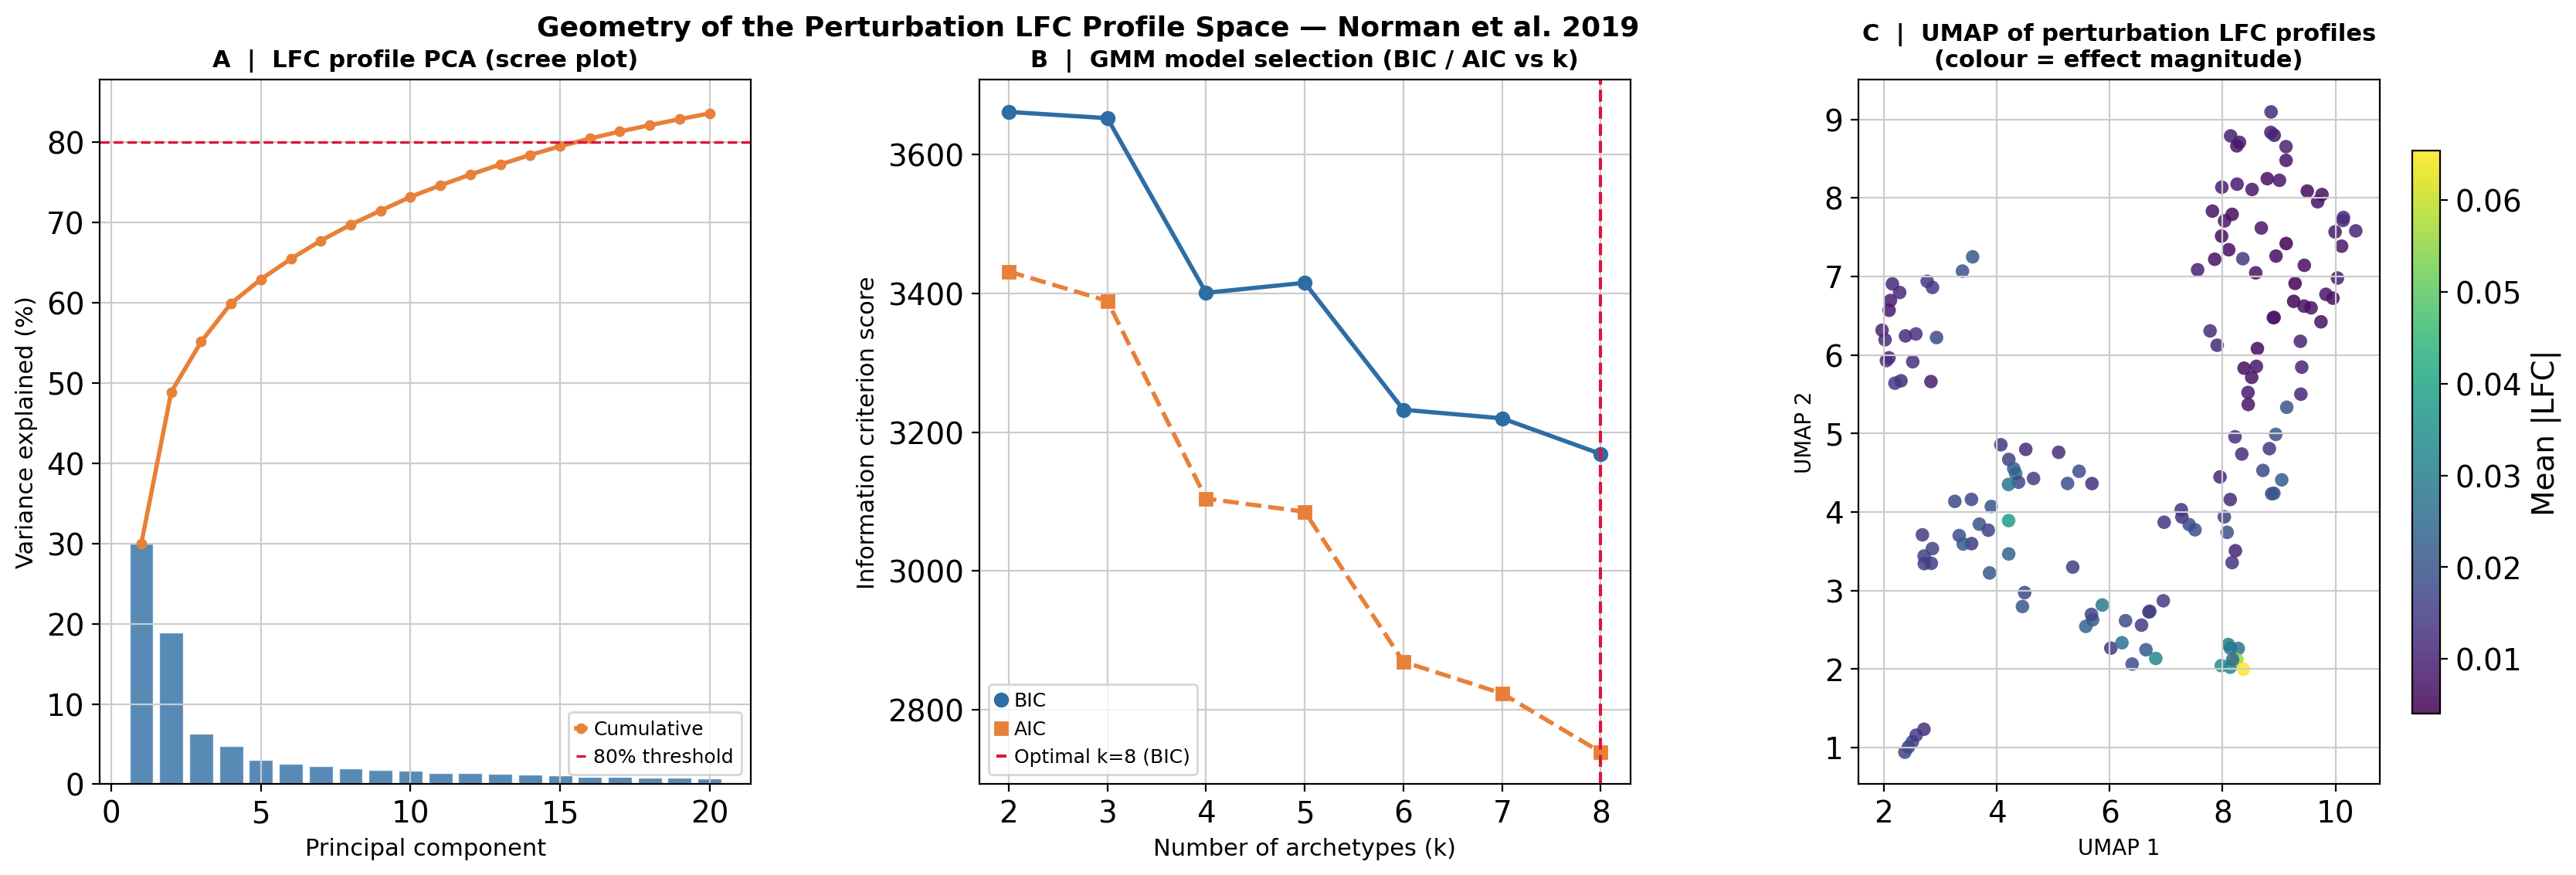

Hopkins H=0.842


In [10]:
# ── Figure 1: LFC space geometry ─────────────────────────────────
fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel A: Scree plot
ax0     = fig.add_subplot(gs[0])
cumvar  = np.cumsum(var_exp[:20]) * 100
ax0.bar(range(1, 21), var_exp[:20] * 100, color=BLUE, alpha=0.8,
        edgecolor="white", linewidth=0.5)
ax0.plot(range(1, 21), cumvar, "o-", color=ORANGE, lw=2,
         markersize=4, label="Cumulative")
ax0.axhline(80, color="crimson", ls="--", lw=1.2, label="80% threshold")
ax0.set_xlabel("Principal component", fontsize=11)
ax0.set_ylabel("Variance explained (%)", fontsize=11)
ax0.set_title("A  |  LFC profile PCA (scree plot)", fontsize=11, fontweight="bold")
ax0.legend(fontsize=9)

# Panel B: BIC/AIC
ax1 = fig.add_subplot(gs[1])
ax1.plot(list(k_range), bic_scores, "o-", color=BLUE, lw=2, markersize=6, label="BIC")
ax1.plot(list(k_range), aic_scores, "s--", color=ORANGE, lw=2, markersize=6, label="AIC")
ax1.axvline(optimal_k_bic, color="crimson", ls="--", lw=1.5,
            label=f"Optimal k={optimal_k_bic} (BIC)")
ax1.set_xlabel("Number of archetypes (k)", fontsize=11)
ax1.set_ylabel("Information criterion score", fontsize=11)
ax1.set_title("B  |  GMM model selection (BIC / AIC vs k)", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)

# Panel C: UMAP coloured by effect magnitude
ax2           = fig.add_subplot(gs[2])
lfc_magnitude = np.abs(L).mean(axis=1)
sc_plot = ax2.scatter(L_umap[:, 0], L_umap[:, 1], c=lfc_magnitude,
                       cmap="viridis", s=40, alpha=0.85, edgecolor="none")
plt.colorbar(sc_plot, ax=ax2, label="Mean |LFC|", shrink=0.8)
ax2.set_xlabel("UMAP 1", fontsize=10)
ax2.set_ylabel("UMAP 2", fontsize=10)
ax2.set_title("""C  |  UMAP of perturbation LFC profiles
(colour = effect magnitude)""",
              fontsize=11, fontweight="bold")

plt.suptitle("Geometry of the Perturbation LFC Profile Space — Norman et al. 2019",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_lfc_geometry.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Hopkins H={H:.3f}")

In [11]:
# ── Map Ensembl IDs to gene symbols ──────────────────────────────
# Check whether var_names are Ensembl IDs
sample_name = gene_names[0]
is_ensembl = sample_name.startswith("ENSG")

if is_ensembl:
    print("Detected Ensembl IDs — mapping to gene symbols via adata.var...")
    # The preprocessed AnnData typically stores symbols in a var column
    print(f"adata.var columns: {list(adata.var.columns)}")
    if "gene_name" in adata.var.columns:
        symbol_map = dict(zip(adata.var_names, adata.var["gene_name"]))
    elif "gene_symbols" in adata.var.columns:
        symbol_map = dict(zip(adata.var_names, adata.var["gene_symbols"]))
    else:
        # Fall back to var_names themselves if no symbol column
        symbol_map = {g: g for g in gene_names}
    display_names = [symbol_map.get(g, g) for g in gene_names]
    print(f"Example: {gene_names[0]} -> {display_names[0]}")
else:
    display_names = gene_names
    symbol_map    = {g: g for g in gene_names}

Detected Ensembl IDs — mapping to gene symbols via adata.var...
adata.var columns: ['gene_name']
Example: ENSG00000239945 -> RP11-34P13.8


## 3. Perturbation Response Archetype Discovery

We fit a GMM to PCA-reduced LFC profiles to discover **perturbation response archetypes** — clusters of perturbations producing transcriptionally similar responses despite targeting different genes.

**Connection to MARS:** Training perturbations define archetype landmarks. Held-out perturbations are assessed against these landmarks; low-confidence assignments define the open-world novelty criterion. Soft posterior probabilities p(archetype|LFC) are the structural analogue of MARS's per-cell cell-type confidence scores.


In [12]:
# ── Train / val / test split (by perturbation identity) ──────────
train_conds, temp_conds = train_test_split(valid_single, test_size=0.2, random_state=42)
val_conds,   test_conds = train_test_split(temp_conds,   test_size=0.5, random_state=42)

train_set = set(train_conds)
val_set   = set(val_conds)
test_set  = set(test_conds)

# Index positions within valid_single
train_idx = [i for i, c in enumerate(valid_single) if c in train_set]
val_idx   = [i for i, c in enumerate(valid_single) if c in val_set]
test_idx  = [i for i, c in enumerate(valid_single) if c in test_set]

L_train = L_pca[train_idx, :10]
L_val   = L_pca[val_idx,   :10]
L_test  = L_pca[test_idx,  :10]

print(f"Train: {len(train_conds):3d} perturbations  |  "
      f"Val: {len(val_conds):3d}  |  Test: {len(test_conds):3d}")
print(f"L_train: {L_train.shape} | L_val: {L_val.shape} | L_test: {L_test.shape}")


Train: 121 perturbations  |  Val:  15  |  Test:  16
L_train: (121, 10) | L_val: (15, 10) | L_test: (16, 10)


In [13]:
# ── Fit GMM on training perturbations only ────────────────────────
K = optimal_k_bic

gmm = GaussianMixture(n_components=K, covariance_type="full",
                       random_state=42, max_iter=500, n_init=5)
gmm.fit(L_train)

train_labels = gmm.predict(L_train)
val_labels   = gmm.predict(L_val)
test_labels  = gmm.predict(L_test)
train_proba  = gmm.predict_proba(L_train)
val_proba    = gmm.predict_proba(L_val)
test_proba   = gmm.predict_proba(L_test)

sil = silhouette_score(L_train, train_labels)
print(f"GMM fitted: K={K} archetypes | Silhouette: {sil:.3f}")
print()
print("Archetype sizes (training):")
for k in range(K):
    mask_k  = (train_labels == k)
    genes_k = [
        valid_single[train_idx[i]].replace("+ctrl","").replace("ctrl+","")
        for i, flag in enumerate(mask_k) if flag
    ]
    print(f"  Archetype {k}: {mask_k.sum():3d} perts  "
          f"e.g. {', '.join(genes_k[:5])}")


GMM fitted: K=8 archetypes | Silhouette: 0.171

Archetype sizes (training):
  Archetype 0:  45 perts  e.g. FOXA1, BCORL1, MEIS1, GLB1L2, FEV
  Archetype 1:   2 perts  e.g. CEBPA, CEBPA
  Archetype 2:  26 perts  e.g. DUSP9, RHOXF2BB, CNN1, CDKN1A, PTPN1
  Archetype 3:   4 perts  e.g. CEBPE, SPI1, CEBPB, SPI1
  Archetype 4:  23 perts  e.g. TSC22D1, MAML2, ELMSAN1, BAK1, RUNX1T1
  Archetype 5:   1 perts  e.g. TP73
  Archetype 6:   8 perts  e.g. ETS2, COL2A1, FOSB, MAPK1, ETS2
  Archetype 7:  12 perts  e.g. TBX3, DLX2, CBFA2T3, CBFA2T3, CELF2


In [14]:
# ── Archetype centroid LFC profiles ──────────────────────────────
archetype_centroids_lfc = {}
archetype_perturbations = {}
TOP_GENES = 30

for k in range(K):
    k_conds = [valid_single[train_idx[i]]
               for i, lab in enumerate(train_labels) if lab == k]
    archetype_perturbations[k] = k_conds
    if k_conds:
        archetype_centroids_lfc[k] = lfc_df[k_conds].mean(axis=1).values
    else:
        archetype_centroids_lfc[k] = np.zeros(len(gene_names))

archetype_signature_genes = {}
for k in range(K):
    c = archetype_centroids_lfc[k]
    archetype_signature_genes[k] = {
        "up":            [display_names[i] for i in np.argsort(c)[::-1][:TOP_GENES]],
        "down":          [display_names[i] for i in np.argsort(c)[:TOP_GENES]],
        "top_magnitude": [display_names[i] for i in np.argsort(np.abs(c))[::-1][:TOP_GENES]]
    }
    print(f"Archetype {k} top up: {', '.join(archetype_signature_genes[k]['up'][:6])}")


Archetype 0 top up: MALAT1, GYPB, NEAT1, HBZ, HBG2, ALAS2
Archetype 1 top up: LST1, CLC, CFD, CSF3R, TYROBP, PNRC1
Archetype 2 top up: HBZ, HBG2, ALAS2, GYPB, HBG1, HBA1
Archetype 3 top up: LST1, AIF1, TYROBP, CFD, ARHGDIB, MALAT1
Archetype 4 top up: HBG2, HBZ, TMSB4X, HBG1, KIF2C, HIST1H1C
Archetype 5 top up: AVP, HBZ, NEAT1, ALAS2, GYPB, MALAT1
Archetype 6 top up: SH3BGRL3, AIF1, COL2A1, CD52, GMFG, S100A11
Archetype 7 top up: TMEM54, VIM, BST2, AVP, RNASET2, NEAT1


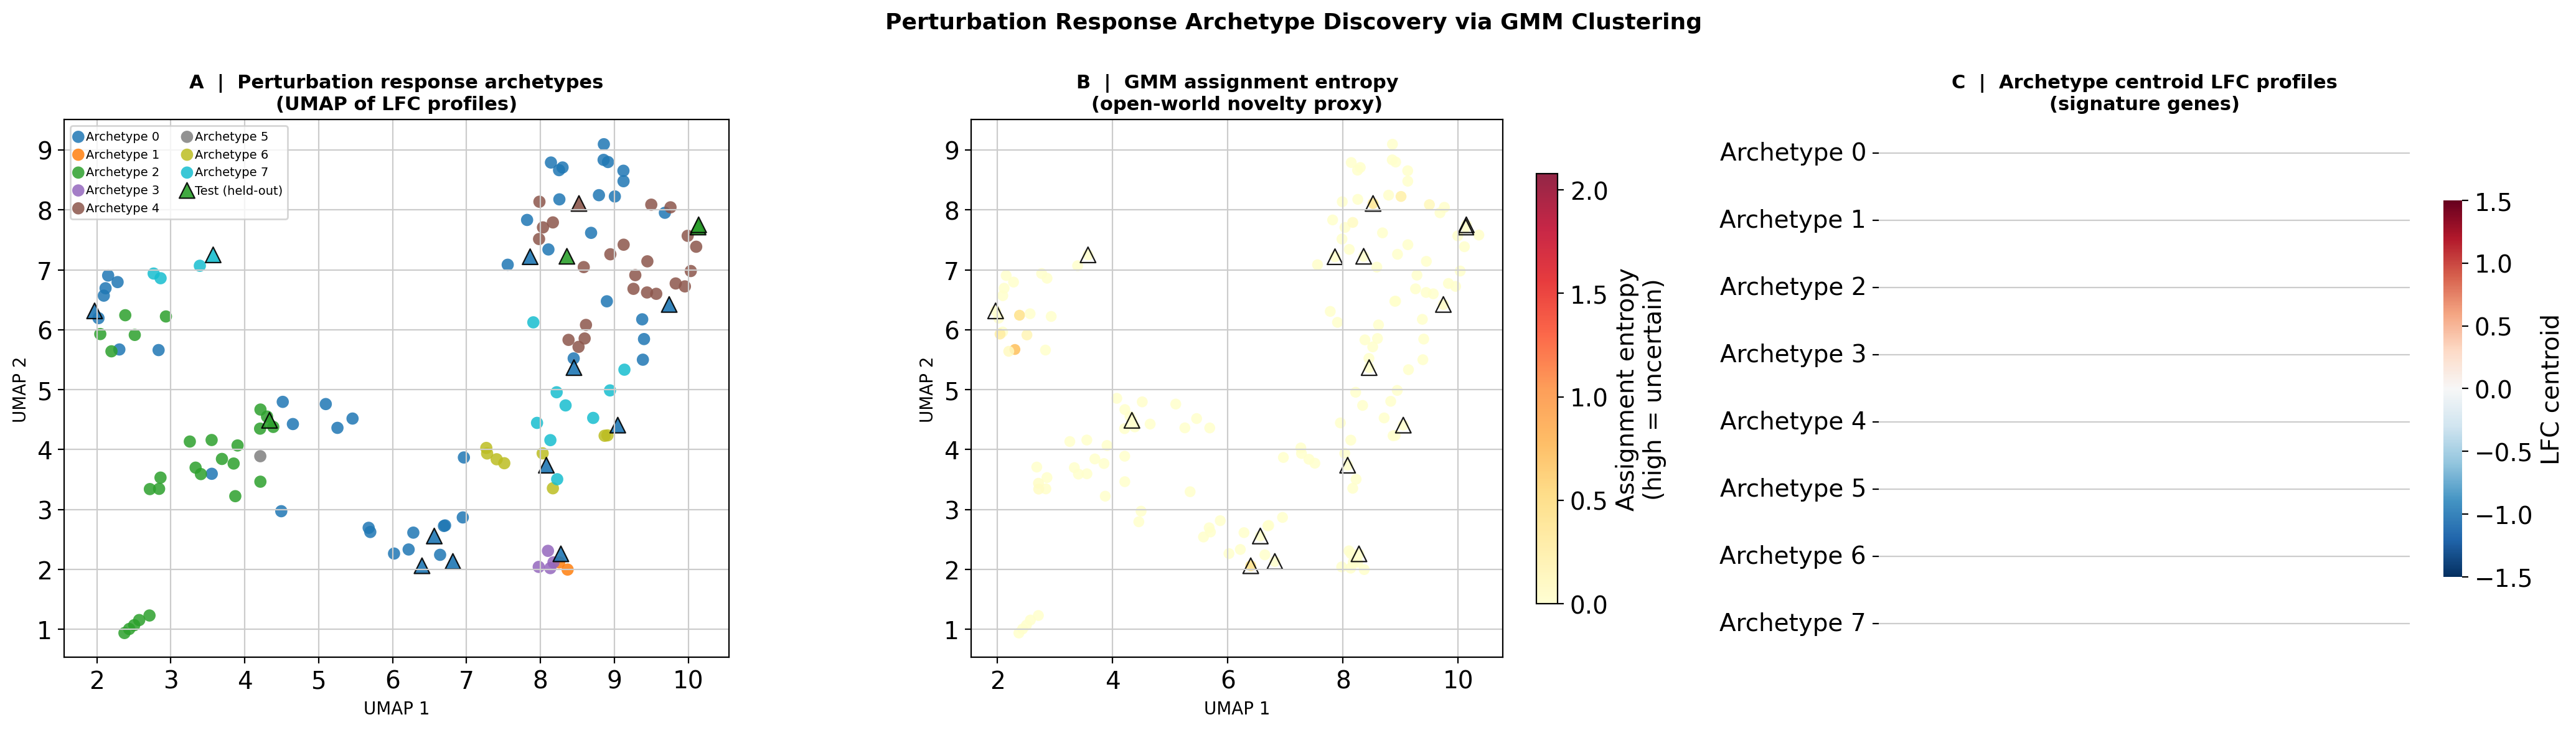

In [15]:
# ── Figure 2: Archetype discovery ────────────────────────────────
cmap_k = matplotlib.colormaps[CMAP_ARCHETYPE].resampled(K)
archetype_colors = {k: cmap_k(k / max(K - 1, 1)) for k in range(K)}

# Build unified label + membership arrays over valid_single
all_labels   = np.full(len(valid_single), -1, dtype=int)
is_train_arr = np.zeros(len(valid_single), dtype=bool)
is_test_arr  = np.zeros(len(valid_single), dtype=bool)

for i, idx in enumerate(train_idx):
    all_labels[idx]   = train_labels[i]
    is_train_arr[idx] = True
for i, idx in enumerate(val_idx):
    all_labels[idx] = val_labels[i]
for i, idx in enumerate(test_idx):
    all_labels[idx]  = test_labels[i]
    is_test_arr[idx] = True

test_positions    = np.where(is_test_arr)[0]
test_pt_colors    = [archetype_colors[all_labels[i]] for i in test_positions]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel A: Archetypes in UMAP
for k in range(K):
    mask_k = (all_labels == k) & is_train_arr
    axes[0].scatter(L_umap[mask_k, 0], L_umap[mask_k, 1],
                    color=archetype_colors[k], s=50, alpha=0.85,
                    edgecolor="none", label=f"Archetype {k}")
axes[0].scatter(L_umap[test_positions, 0], L_umap[test_positions, 1],
                c=test_pt_colors, s=80, alpha=0.9,
                edgecolor="black", linewidth=0.8, marker="^",
                label="Test (held-out)")
axes[0].set_xlabel("UMAP 1", fontsize=10)
axes[0].set_ylabel("UMAP 2", fontsize=10)
axes[0].set_title("""A  |  Perturbation response archetypes
(UMAP of LFC profiles)""",
                  fontsize=11, fontweight="bold")
axes[0].legend(fontsize=7, ncol=2)

# Panel B: Assignment entropy
full_proba  = gmm.predict_proba(L_pca[:, :10])
entropy     = -np.sum(full_proba * np.log(full_proba + 1e-10), axis=1)
sc2 = axes[1].scatter(L_umap[:, 0], L_umap[:, 1], c=entropy,
                       cmap="YlOrRd", s=40, alpha=0.85,
                       edgecolor="none", vmin=0, vmax=np.log(K))
plt.colorbar(sc2, ax=axes[1], label="""Assignment entropy
(high = uncertain)""", shrink=0.8)
axes[1].scatter(L_umap[test_positions, 0], L_umap[test_positions, 1],
                s=80, alpha=0.9, edgecolor="black", linewidth=0.8,
                facecolors="none", marker="^")
axes[1].set_xlabel("UMAP 1", fontsize=10)
axes[1].set_ylabel("UMAP 2", fontsize=10)
axes[1].set_title("""B  |  GMM assignment entropy
(open-world novelty proxy)""",
                  fontsize=11, fontweight="bold")

# Panel C: Centroid heatmap
sig_gene_union = []
for k in range(K):
    sig_gene_union.extend(archetype_signature_genes[k]["top_magnitude"][:8])
sig_gene_union  = list(dict.fromkeys(sig_gene_union))
sig_idx         = [gene_names.index(g) for g in sig_gene_union if g in gene_names]
centroid_matrix = np.stack([archetype_centroids_lfc[k] for k in range(K)])
hm_data         = centroid_matrix[:, sig_idx]

sns.heatmap(hm_data, cmap="RdBu_r", center=0, vmin=-1.5, vmax=1.5,
            ax=axes[2],
            xticklabels=[gene_names[i] for i in sig_idx],
            yticklabels=[f"Archetype {k}" for k in range(K)],
            cbar_kws={"label": "LFC centroid", "shrink": 0.7})
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right", fontsize=6)
axes[2].set_title("""C  |  Archetype centroid LFC profiles
(signature genes)""",
                  fontsize=11, fontweight="bold")

plt.suptitle("Perturbation Response Archetype Discovery via GMM Clustering",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_archetypes.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Biological Characterisation of Response Archetypes

Archetypes are only meaningful if they correspond to biologically coherent regulatory programmes. We characterise each archetype through pathway enrichment of upregulated signature genes, transcription factor identity, and summary statistics of perturbation effect magnitudes.


In [16]:
# ── Pathway enrichment per archetype ─────────────────────────────
try:
    import gseapy as gp
    GSEAPY_AVAILABLE = True
except ImportError:
    GSEAPY_AVAILABLE = False

archetype_enrichment = {}
for k in range(K):
    up_genes = archetype_signature_genes[k]["up"]
    if GSEAPY_AVAILABLE:
        try:
            enr = gp.enrichr(
                gene_list=up_genes,
                gene_sets=["KEGG_2021_Human", "MSigDB_Hallmark_2020"],
                organism="human", outdir=None, verbose=False
            )
            archetype_enrichment[k] = (enr.results
                                          .sort_values("Adjusted P-value")
                                          .head(5)[["Term","Adjusted P-value"]])
        except Exception:
            archetype_enrichment[k] = None
    else:
        archetype_enrichment[k] = None

print("ARCHETYPE BIOLOGICAL CHARACTERISATION")
print("=" * 60)
for k in range(K):
    n_perts    = len(archetype_perturbations[k])
    tgt_genes  = [c.replace("+ctrl","").replace("ctrl+","")
                  for c in archetype_perturbations[k]]
    up_genes   = archetype_signature_genes[k]["up"][:8]
    down_genes = archetype_signature_genes[k]["down"][:4]
    print(f"\nArchetype {k}  ({n_perts} training perturbations)")
    print(f"  Perturbed genes: {', '.join(tgt_genes[:8])}")
    print(f"  Top upregulated: {', '.join(up_genes)}")
    print(f"  Top downreg:     {', '.join(down_genes)}")
    if GSEAPY_AVAILABLE and archetype_enrichment[k] is not None:
        for _, row in archetype_enrichment[k].head(3).iterrows():
            print(f"  Pathway: {row['Term'][:55]}  "
                  f"(padj={row['Adjusted P-value']:.2e})")


ARCHETYPE BIOLOGICAL CHARACTERISATION

Archetype 0  (45 training perturbations)
  Perturbed genes: FOXA1, BCORL1, MEIS1, GLB1L2, FEV, FEV, LHX1, RREB1
  Top upregulated: MALAT1, GYPB, NEAT1, HBZ, HBG2, ALAS2, GYPA, AC006262.5
  Top downreg:     GAL, NME1, PRSS57, UBE2S
  Pathway: heme Metabolism  (padj=8.00e-09)
  Pathway: UV Response Up  (padj=1.04e-02)
  Pathway: Hypoxia  (padj=1.04e-02)

Archetype 1  (2 training perturbations)
  Perturbed genes: CEBPA, CEBPA
  Top upregulated: LST1, CLC, CFD, CSF3R, TYROBP, PNRC1, VIM, MS4A3
  Top downreg:     NME1, RANBP1, SRM, PTMA

Archetype 2  (26 training perturbations)
  Perturbed genes: DUSP9, RHOXF2BB, CNN1, CDKN1A, PTPN1, PTPN12, CKS1B, CLDN6
  Top upregulated: HBZ, HBG2, ALAS2, GYPB, HBG1, HBA1, NEAT1, MALAT1
  Top downreg:     HIST1H4C, PRSS57, TEX30, UBE2S
  Pathway: heme Metabolism  (padj=3.22e-12)
  Pathway: Malaria  (padj=2.05e-07)
  Pathway: Porphyrin and chlorophyll metabolism  (padj=1.20e-02)

Archetype 3  (4 training perturbations

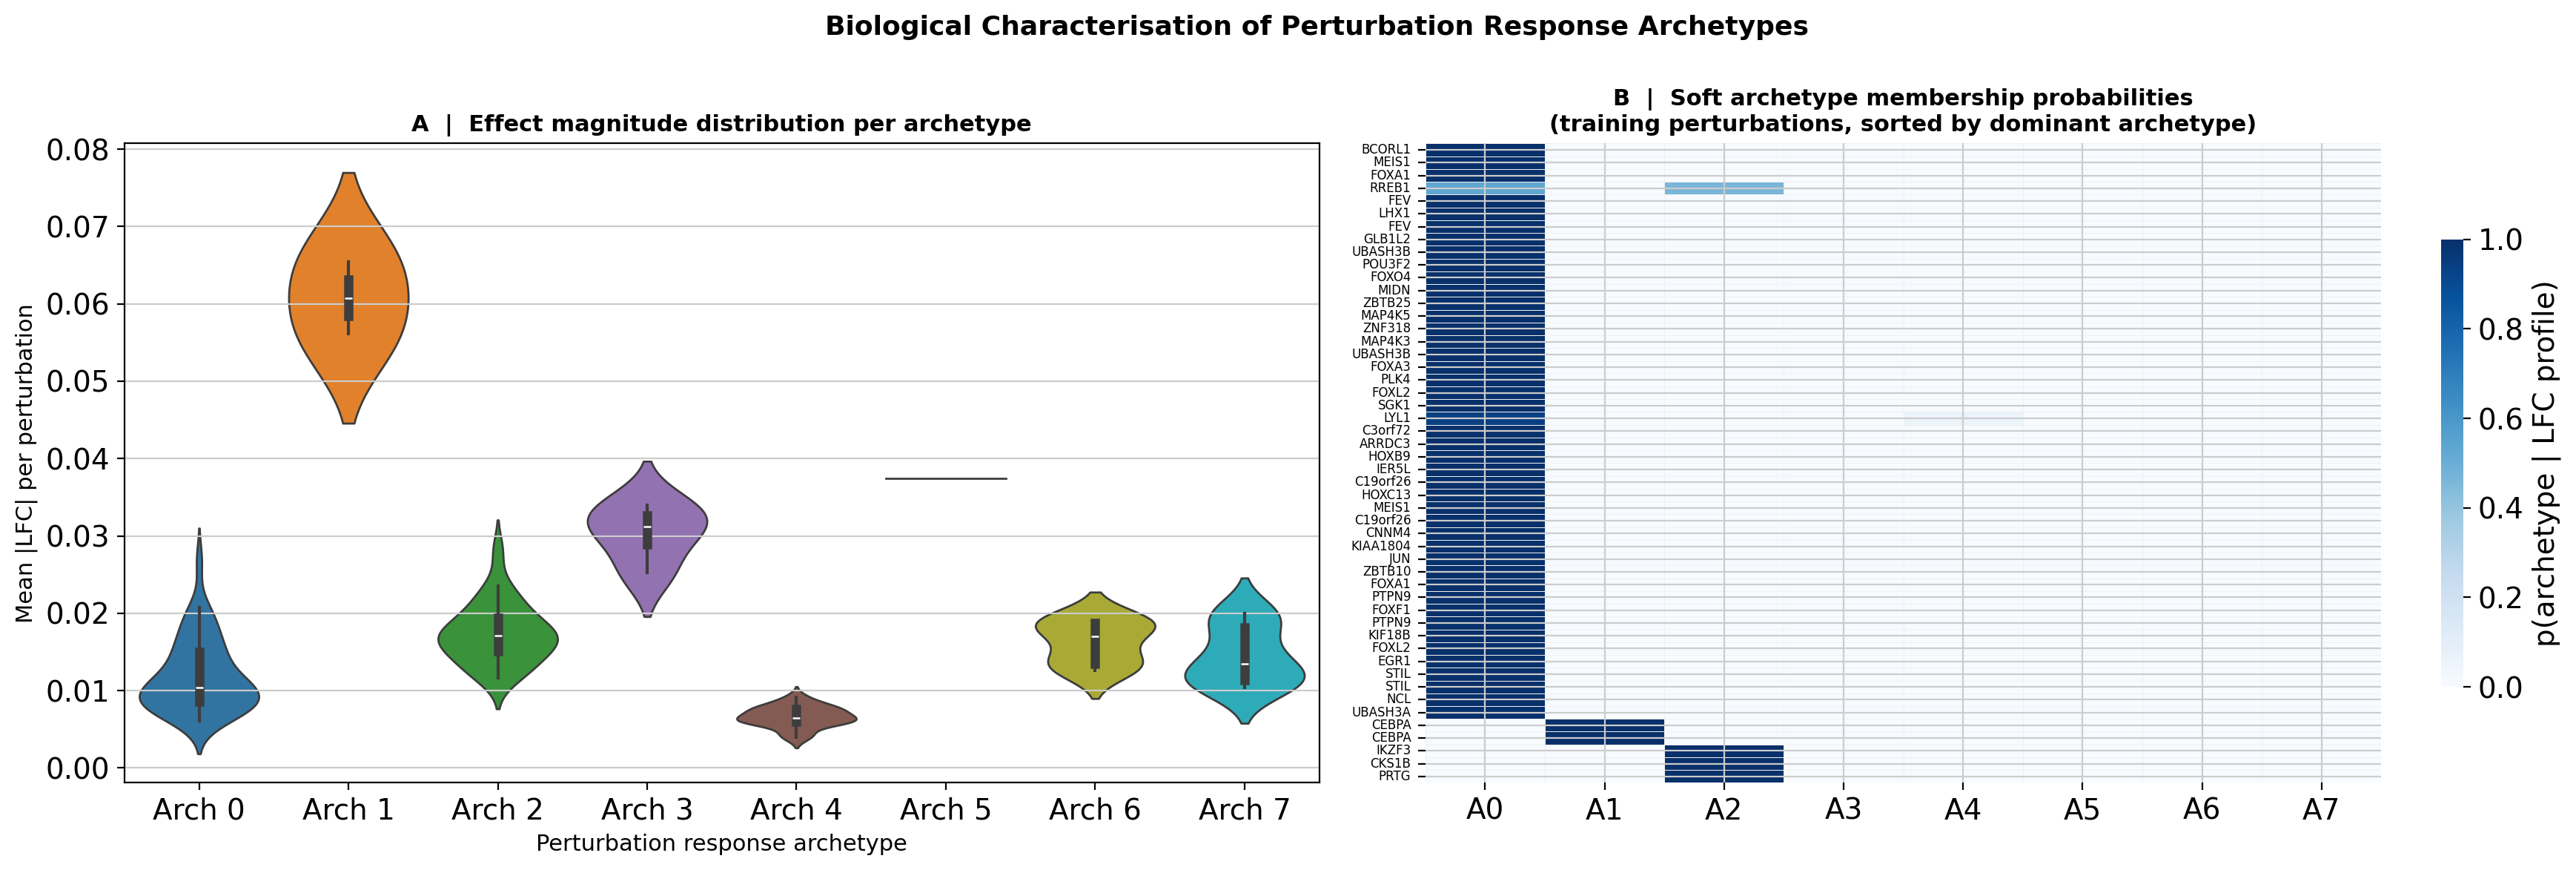

In [17]:
# ── Figure 3: Archetype biology ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel A: Effect magnitude violin per archetype
lfc_vals, arch_ids = [], []
for k in range(K):
    for i, flag in enumerate(train_labels == k):
        if flag:
            cond = valid_single[train_idx[i]]
            if cond in lfc_df.columns:
                lfc_vals.append(np.abs(lfc_df[cond].values).mean())
                arch_ids.append(f"Arch {k}")

violin_df = pd.DataFrame({"Mean |LFC|": lfc_vals, "Archetype": arch_ids})
order     = [f"Arch {k}" for k in range(K)]
pal       = {f"Arch {k}": archetype_colors[k] for k in range(K)}
sns.violinplot(data=violin_df, x="Archetype", y="Mean |LFC|",
               order=order, palette=pal, ax=axes[0],
               inner="box", linewidth=1.0)
axes[0].set_xlabel("Perturbation response archetype", fontsize=11)
axes[0].set_ylabel("Mean |LFC| per perturbation", fontsize=11)
axes[0].set_title("A  |  Effect magnitude distribution per archetype",
                  fontsize=11, fontweight="bold")

# Panel B: Soft membership probability heatmap
n_disp   = min(50, len(train_proba))
sort_ord = np.argsort(np.argmax(train_proba, axis=1))[:n_disp]
disp_lbl = [
    valid_single[train_idx[i]].replace("+ctrl","").replace("ctrl+","")
    for i in sort_ord
]
sns.heatmap(train_proba[sort_ord],
            cmap="Blues", vmin=0, vmax=1,
            xticklabels=[f"A{k}" for k in range(K)],
            yticklabels=disp_lbl,
            ax=axes[1],
            cbar_kws={"label": "p(archetype | LFC profile)", "shrink": 0.7},
            linewidths=0.2, linecolor="#F0F0F0")
plt.setp(axes[1].get_yticklabels(), fontsize=6)
axes[1].set_title("""B  |  Soft archetype membership probabilities
(training perturbations, sorted by dominant archetype)""",
                  fontsize=11, fontweight="bold")

plt.suptitle("Biological Characterisation of Perturbation Response Archetypes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_archetype_biology.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Open-World Novelty Scoring

**Definition:**
N(q) = 1 - max_k p(k | LFC_q)

A perturbation whose response fits no archetype has near-uniform posteriors, yielding high N(q). A well-characterised perturbation matching one archetype confidently has N(q) near 0.

This is the structural analogue of MARS's per-cell novelty criterion. The key empirical question: does N(q) predict prediction difficulty on held-out perturbations?


In [18]:
# ── Novelty score via log-likelihood distance ─────────────────────
# More robust than max-posterior for tight GMMs
# N(q) = -log p(q) normalised by training distribution

def novelty_score_loglik(X, gmm_model, train_X):
    log_probs      = gmm_model.score_samples(X)          # log p(x)
    train_log_prob = gmm_model.score_samples(train_X)
    # Normalise: how many std deviations below the training mean?
    mu    = train_log_prob.mean()
    sigma = train_log_prob.std() + 1e-8
    # Novelty = negative normalised log-likelihood (higher = more novel)
    novelty = -(log_probs - mu) / sigma
    # Clip to [0,1] range via sigmoid
    novelty = 1 / (1 + np.exp(-novelty * 0.5))
    return novelty

novelty_train = novelty_score_loglik(L_train, gmm, L_train)
novelty_val   = novelty_score_loglik(L_val,   gmm, L_train)
novelty_test  = novelty_score_loglik(L_test,  gmm, L_train)

NOVELTY_THRESHOLD = np.percentile(novelty_train, 90)

In [19]:
# ── Evaluate additive baseline on test set ────────────────────────
train_mean_lfc = lfc_df[train_conds].mean(axis=1).values

per_test_results = []
for i, idx in enumerate(test_idx):
    cond = valid_single[idx]
    if cond not in lfc_df.columns:
        continue
    deg_idx   = top_degs.get(cond, np.arange(20))
    true_expr = mean_expr_df[cond].values
    pred_expr = ctrl_mean + train_mean_lfc

    mse_deg   = mean_squared_error(true_expr[deg_idx], pred_expr[deg_idx])
    r_deg, _  = pearsonr(true_expr[deg_idx], pred_expr[deg_idx])

    per_test_results.append({
        "condition": cond,
        "novelty":   novelty_test[i],
        "archetype": test_labels[i],
        "mse_deg":   mse_deg,
        "pearson_r": r_deg,
        "difficulty":1.0 - r_deg,
        "is_novel":  novelty_test[i] > NOVELTY_THRESHOLD,
    })

perf_df = pd.DataFrame(per_test_results)
r_nov_diff, p_nov = pearsonr(perf_df["novelty"], perf_df["difficulty"])
id_perf  = perf_df[~perf_df["is_novel"]]
ow_perf  = perf_df[perf_df["is_novel"]]

print("=" * 55)
print("CORE FINDING: Novelty -> Prediction Difficulty")
print("=" * 55)
print(f"Pearson r (novelty vs difficulty): {r_nov_diff:.3f}  (p={p_nov:.3e})")
print(f"In-distribution   Pearson r: {id_perf['pearson_r'].mean():.3f}")
print(f"Open-world novel  Pearson r: {ow_perf['pearson_r'].mean():.3f}")
if len(ow_perf) > 0 and len(id_perf) > 0:
    delta = ow_perf['pearson_r'].mean() - id_perf['pearson_r'].mean()
    print(f"Delta (OW - ID):              {delta:+.3f}")


CORE FINDING: Novelty -> Prediction Difficulty
Pearson r (novelty vs difficulty): 0.559  (p=2.443e-02)
In-distribution   Pearson r: 0.957
Open-world novel  Pearson r: 0.763
Delta (OW - ID):              -0.195


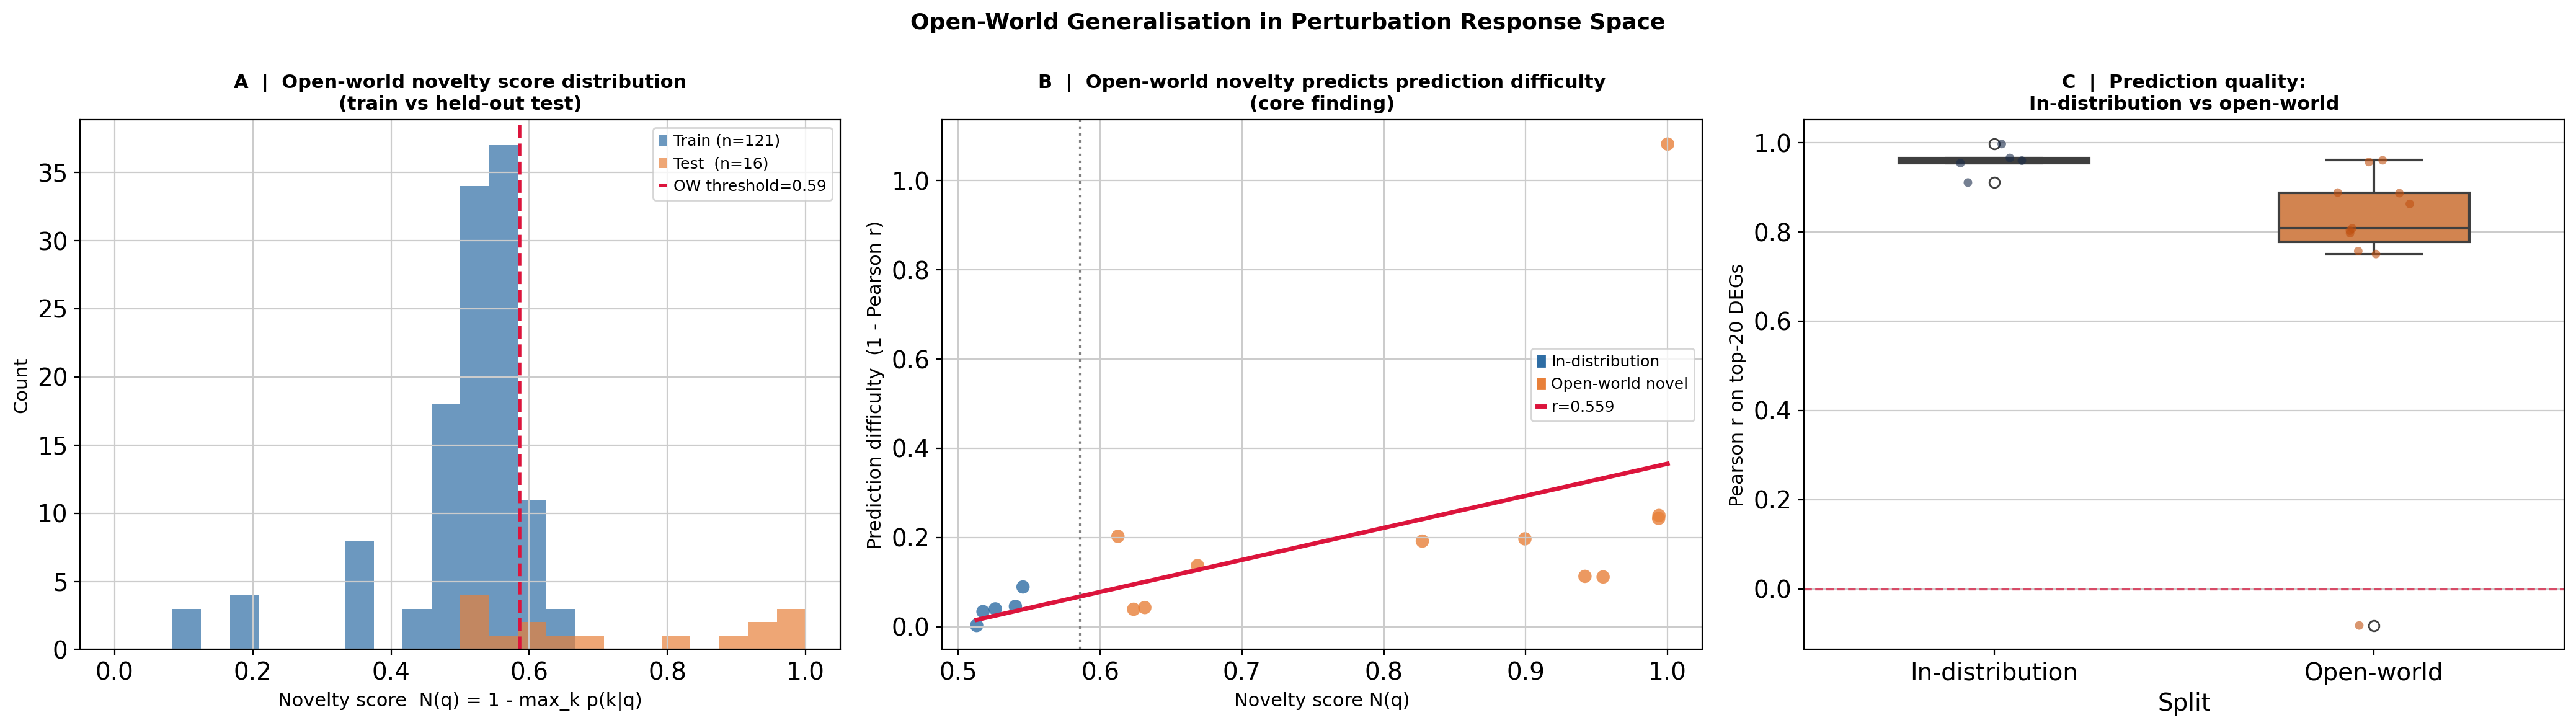

In [20]:
# ── Figure 4: Open-world novelty & prediction difficulty ──────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel A: Novelty distributions
bins = np.linspace(0, 1, 25)
axes[0].hist(novelty_train, bins=bins, alpha=0.7, color=BLUE,
             label=f"Train (n={len(novelty_train)})", edgecolor="none")
axes[0].hist(novelty_test,  bins=bins, alpha=0.7, color=ORANGE,
             label=f"Test  (n={len(novelty_test)})",  edgecolor="none")
axes[0].axvline(NOVELTY_THRESHOLD, color="crimson", ls="--", lw=2,
                label=f"OW threshold={NOVELTY_THRESHOLD:.2f}")
axes[0].set_xlabel("Novelty score  N(q) = 1 - max_k p(k|q)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("""A  |  Open-world novelty score distribution
(train vs held-out test)""",
                  fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)

# Panel B: Novelty vs difficulty scatter
pt_colors = [ORANGE if r else BLUE for r in perf_df["is_novel"]]
axes[1].scatter(perf_df["novelty"], perf_df["difficulty"],
                c=pt_colors, alpha=0.8, s=60, edgecolor="none")
x_line = np.linspace(perf_df["novelty"].min(), perf_df["novelty"].max(), 100)
m, b   = np.polyfit(perf_df["novelty"], perf_df["difficulty"], 1)
axes[1].plot(x_line, m * x_line + b, "crimson", lw=2.5,
             label=f"r={r_nov_diff:.3f}, p={p_nov:.2e}")
axes[1].axvline(NOVELTY_THRESHOLD, color="grey", ls=":", lw=1.5)
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color=BLUE,   label="In-distribution"),
    Patch(color=ORANGE, label="Open-world novel"),
    plt.Line2D([0],[0], color="crimson", lw=2.5,
               label=f"r={r_nov_diff:.3f}")
], fontsize=9)
axes[1].set_xlabel("Novelty score N(q)", fontsize=11)
axes[1].set_ylabel("Prediction difficulty  (1 - Pearson r)", fontsize=11)
axes[1].set_title("""B  |  Open-world novelty predicts prediction difficulty
(core finding)""",
                  fontsize=11, fontweight="bold")

# Panel C: Box comparison ID vs OW
perf_compare = pd.DataFrame({
    "Split":   (["In-distribution"] * len(id_perf) + ["Open-world"] * len(ow_perf)),
    "Pearson r (DEGs)": list(id_perf["pearson_r"]) + list(ow_perf["pearson_r"])
})
sns.boxplot(data=perf_compare, x="Split", y="Pearson r (DEGs)",
            palette={"In-distribution": BLUE, "Open-world": ORANGE},
            ax=axes[2], width=0.5, linewidth=1.5)
sns.stripplot(data=perf_compare, x="Split", y="Pearson r (DEGs)",
              palette={"In-distribution": NAVY, "Open-world": "#C05010"},
              ax=axes[2], size=5, alpha=0.6, jitter=True)
axes[2].axhline(0, color="crimson", ls="--", lw=1.2, alpha=0.7)
axes[2].set_title("""C  |  Prediction quality:
In-distribution vs open-world""",
                  fontsize=11, fontweight="bold")
axes[2].set_ylabel("Pearson r on top-20 DEGs", fontsize=11)

plt.suptitle("Open-World Generalisation in Perturbation Response Space",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_open_world.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Gene Co-expression Anchors for Zero-Shot Archetype Prediction

In SATURN, protein language model embeddings serve as species-independent anchors, enabling zero-shot cell embedding for unobserved species. We implement the structural analogue: **gene co-expression neighbourhood** as an anchor that predicts a perturbed gene's response archetype from gene identity alone — before observing any perturbed cells.

Pipeline:
1. Build gene co-expression graph from training cells
2. Compute each perturbed gene's neighbourhood LFC signature
3. Train a classifier: neighbourhood signature -> archetype (training perturbations only)
4. Apply to test genes: zero-shot archetype prediction
5. Use predicted archetype centroid as an improved response baseline


In [21]:
# ── Co-expression graph ───────────────────────────────────────────
print("Building gene co-expression graph from training cells...")
train_cell_mask = (
    pd.Series(adata.obs["condition"].values).isin(train_conds).values | ctrl_mask
)
X_train_cells = X_dense[train_cell_mask]

gene_vars    = X_train_cells.var(axis=0)
top_g_idx    = np.argsort(gene_vars)[::-1][:1000]
top_g_names  = np.array(gene_names)[top_g_idx]
gene_to_node = {g: i for i, g in enumerate(top_g_names)}

corr = np.corrcoef(X_train_cells[:, top_g_idx].T)
G_coexp = nx.Graph()
G_coexp.add_nodes_from(range(len(top_g_names)))
thresh   = 0.35
rows, cols = np.where((np.abs(corr) > thresh) &
                       (np.arange(1000)[:, None] != np.arange(1000)[None, :]))
edges = [(r, c) for r, c in zip(rows, cols) if r < c]
G_coexp.add_edges_from(edges[:8000])
print(f"Co-expression graph: {G_coexp.number_of_nodes()} nodes, "
      f"{G_coexp.number_of_edges()} edges | density={nx.density(G_coexp):.4f}")


Building gene co-expression graph from training cells...
Co-expression graph: 1000 nodes, 450 edges | density=0.0009


In [22]:
# ── Neighbourhood LFC signatures ─────────────────────────────────
K_NN = 10

def get_neighbourhood_signature(target_gene, G, gene_to_node,
                                  all_top_names, k=10):
    sig = np.zeros(len(all_top_names))
    if target_gene not in gene_to_node:
        return sig
    node = gene_to_node[target_gene]
    nbrs = sorted(G.neighbors(node))[:k]
    nbr_genes = [all_top_names[n] for n in nbrs if n < len(all_top_names)]
    if not nbr_genes:
        return sig
    # Mean LFC of neighbour genes across all training perturbations
    nbr_in_hvg = [g for g in nbr_genes if g in gene_names]
    for j, g in enumerate(top_g_names):
        if g in gene_names:
            g_idx = gene_names.index(g)
            vals  = [lfc_df[c].iloc[g_idx]
                     for c in train_conds if c in lfc_df.columns]
            if vals:
                sig[j] = np.mean(vals)
    return sig

# Build feature matrix for training perturbations
print("Computing neighbourhood signatures...")
X_anch_train, y_anch_train = [], []
for cond in train_conds:
    gene = cond.replace("+ctrl","").replace("ctrl+","")
    sig  = get_neighbourhood_signature(gene, G_coexp, gene_to_node,
                                        top_g_names, k=K_NN)
    X_anch_train.append(sig)
    if cond in valid_single:
        tidx = train_idx[list(train_conds).index(cond)] if cond in train_conds else -1
        if cond in valid_single:
            vi = valid_single.index(cond)
            if vi in train_idx:
                y_anch_train.append(train_labels[train_idx.index(vi)])
            else:
                y_anch_train.append(-1)
        else:
            y_anch_train.append(-1)
    else:
        y_anch_train.append(-1)

X_anch_arr = np.array(X_anch_train)
y_anch_arr = np.array(y_anch_train)
valid_mask = y_anch_arr >= 0
print(f"Anchor feature matrix (valid): {X_anch_arr[valid_mask].shape}")


Computing neighbourhood signatures...
Anchor feature matrix (valid): (121, 1000)


In [23]:
# ── Train archetype classifier ────────────────────────────────────
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=42, C=1.0))
])
X_clf = X_anch_arr[valid_mask]
y_clf = y_anch_arr[valid_mask]

cv_scores = cross_val_score(clf, X_clf, y_clf, cv=5, scoring="accuracy")
print(f"Gene-anchor classifier (5-fold CV):")
print(f"  Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print(f"  Chance:   {1/K:.3f}  |  Improvement: {cv_scores.mean()-1/K:+.3f}")

clf.fit(X_clf, y_clf)

# Predict for test perturbations
X_anch_test, y_true_test, test_conds_eval = [], [], []
for i, idx in enumerate(test_idx):
    cond = valid_single[idx]
    gene = cond.replace("+ctrl","").replace("ctrl+","")
    sig  = get_neighbourhood_signature(gene, G_coexp, gene_to_node,
                                        top_g_names, k=K_NN)
    X_anch_test.append(sig)
    y_true_test.append(test_labels[i])
    test_conds_eval.append(cond)

X_anch_test_arr = np.array(X_anch_test)
y_pred_test     = clf.predict(X_anch_test_arr)
y_true_test_arr = np.array(y_true_test)
test_acc        = accuracy_score(y_true_test_arr, y_pred_test)
print(f"\nZero-shot test accuracy: {test_acc:.3f}  (chance={1/K:.3f})")


Gene-anchor classifier (5-fold CV):
  Accuracy: 0.372 +/- 0.006
  Chance:   0.125  |  Improvement: +0.247

Zero-shot test accuracy: 0.625  (chance=0.125)


In [24]:
# ── Archetype-aware prediction vs global baseline ─────────────────
comp_results = []
for i, cond in enumerate(test_conds_eval):
    if cond not in lfc_df.columns:
        continue
    deg_idx   = top_degs.get(cond, np.arange(20))
    true_expr = mean_expr_df[cond].values

    # Global mean LFC baseline
    pred_global = ctrl_mean + train_mean_lfc
    r_global, _ = pearsonr(true_expr[deg_idx], pred_global[deg_idx])

    # Predicted archetype centroid
    pred_arch_id  = int(y_pred_test[i])
    pred_arch_lfc = archetype_centroids_lfc[pred_arch_id]
    pred_archtype = ctrl_mean + pred_arch_lfc
    r_arch, _     = pearsonr(true_expr[deg_idx], pred_archtype[deg_idx])

    # Oracle (true archetype centroid)
    true_arch_id  = int(y_true_test_arr[i])
    pred_oracle   = ctrl_mean + archetype_centroids_lfc[true_arch_id]
    r_oracle, _   = pearsonr(true_expr[deg_idx], pred_oracle[deg_idx])

    comp_results.append({
        "condition":    cond,
        "novelty":      novelty_test[i] if i < len(novelty_test) else np.nan,
        "arch_correct": pred_arch_id == true_arch_id,
        "r_global":     r_global,
        "r_archetype":  r_arch,
        "r_oracle":     r_oracle,
        "delta_r":      r_arch - r_global,
    })

comp_df  = pd.DataFrame(comp_results)
wins_pct = (comp_df["r_archetype"] > comp_df["r_global"]).mean() * 100

print("ARCHETYPE-AWARE PREDICTION RESULTS")
print("=" * 50)
for model, col in [("Global mean LFC",       "r_global"),
                    ("Gene-anchor archetype", "r_archetype"),
                    ("Oracle archetype",      "r_oracle")]:
    print(f"  {model:<28} r={comp_df[col].mean():.3f} "
          f"(median={comp_df[col].median():.3f})")
print(f"\nGene-anchor beats global: {wins_pct:.1f}% of test perturbations")


ARCHETYPE-AWARE PREDICTION RESULTS
  Global mean LFC              r=0.824 (median=0.888)
  Gene-anchor archetype        r=0.820 (median=0.883)
  Oracle archetype             r=0.822 (median=0.906)

Gene-anchor beats global: 31.2% of test perturbations


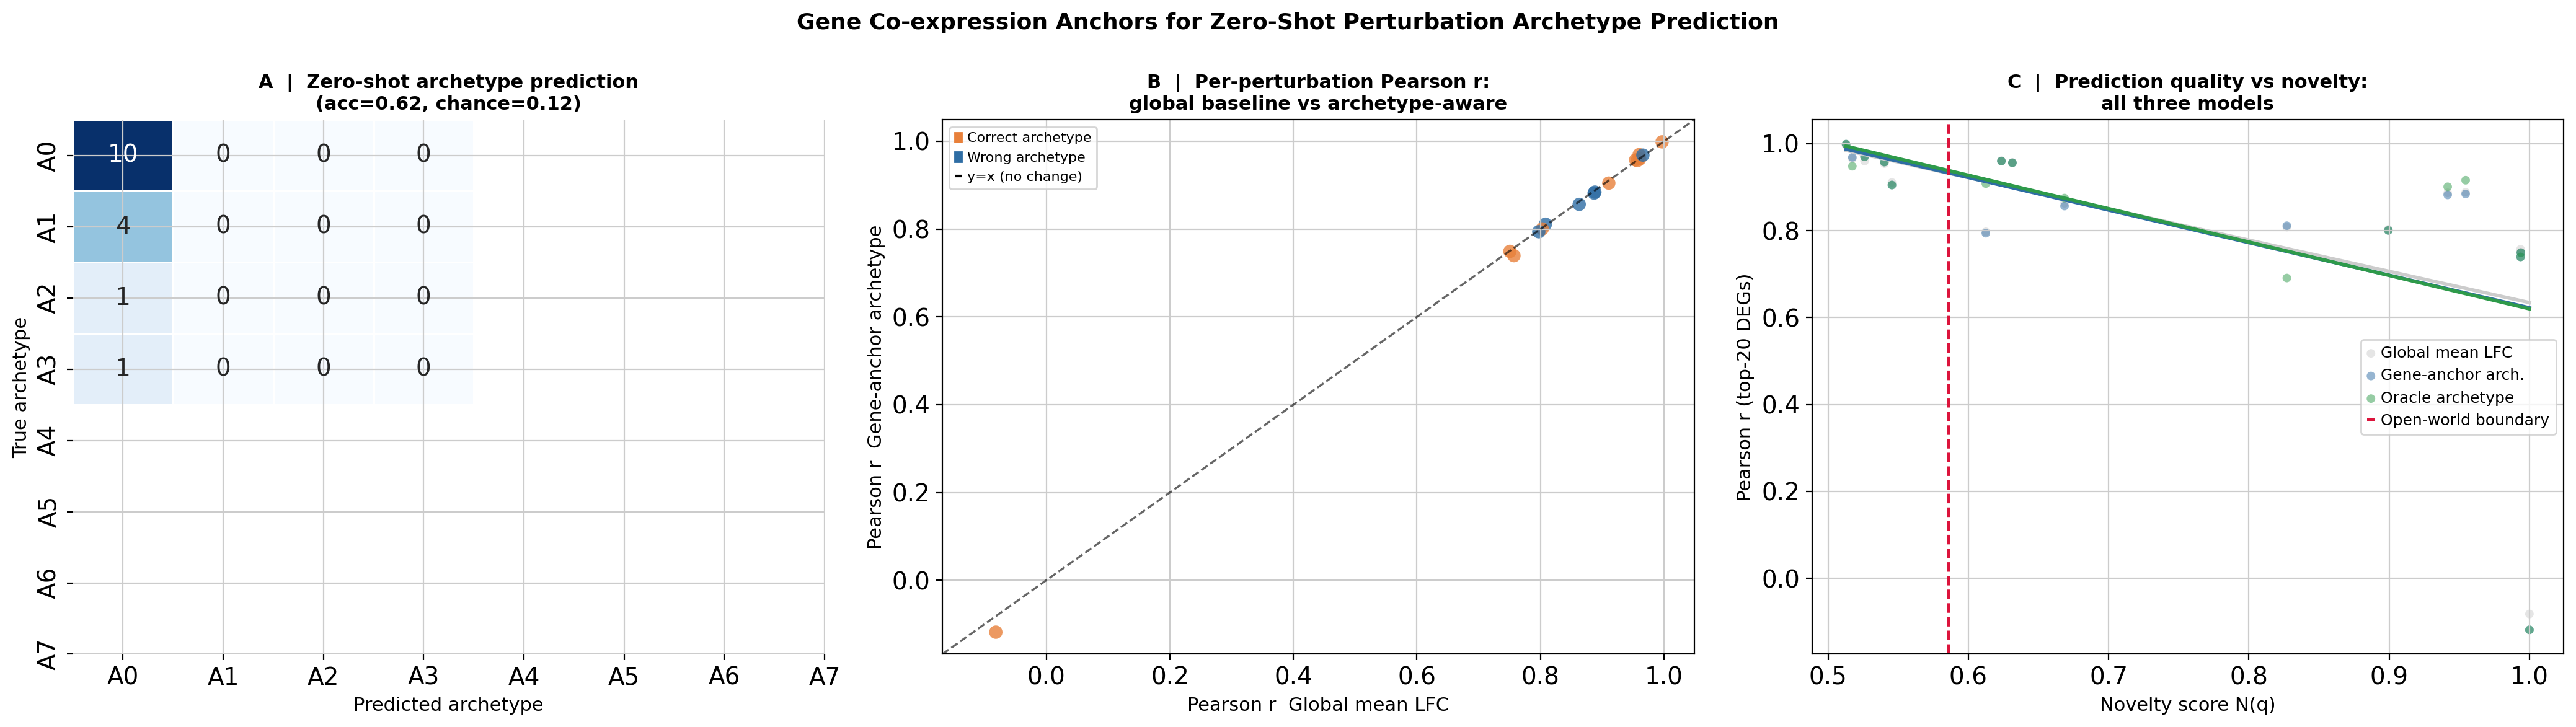

In [25]:
# ── Figure 5: Gene-anchor results ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel A: Confusion matrix
cm = confusion_matrix(comp_df["arch_correct"].apply(lambda x: 1 if x else 0),
                      comp_df["arch_correct"].apply(lambda x: 1 if x else 0))
cm_full = confusion_matrix(y_true_test_arr, y_pred_test)
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"A{k}" for k in range(K)],
            yticklabels=[f"A{k}" for k in range(K)],
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set_xlabel("Predicted archetype", fontsize=11)
axes[0].set_ylabel("True archetype", fontsize=11)
axes[0].set_title(f"""A  |  Zero-shot archetype prediction
(acc={test_acc:.2f}, chance={1/K:.2f})""",
                  fontsize=11, fontweight="bold")

# Panel B: Scatter global vs archetype Pearson r
pt_c = [ORANGE if r else BLUE for r in comp_df["arch_correct"]]
axes[1].scatter(comp_df["r_global"], comp_df["r_archetype"],
                c=pt_c, alpha=0.8, s=60, edgecolor="none")
lims = [
    min(comp_df["r_global"].min(), comp_df["r_archetype"].min()) - 0.05,
    max(comp_df["r_global"].max(), comp_df["r_archetype"].max()) + 0.05
]
axes[1].plot(lims, lims, "k--", lw=1.2, alpha=0.6)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color=ORANGE, label="Correct archetype"),
    Patch(color=BLUE,   label="Wrong archetype"),
    plt.Line2D([0],[0], color="k", ls="--", label="y=x (no change)")
], fontsize=8)
axes[1].set_xlabel("Pearson r  Global mean LFC", fontsize=11)
axes[1].set_ylabel("Pearson r  Gene-anchor archetype", fontsize=11)
axes[1].set_title("""B  |  Per-perturbation Pearson r:
global baseline vs archetype-aware""",
                  fontsize=11, fontweight="bold")

# Panel C: All three models vs novelty
for col, label, color in [
    ("r_global",    "Global mean LFC",   GREY),
    ("r_archetype", "Gene-anchor arch.", BLUE),
    ("r_oracle",    "Oracle archetype",  GREEN),
]:
    nov_vals = comp_df["novelty"].dropna()
    r_vals   = comp_df.loc[comp_df["novelty"].notna(), col]
    axes[2].scatter(nov_vals, r_vals, alpha=0.5, s=25,
                    color=color, edgecolor="none", label=label)
    if len(nov_vals) > 3:
        m2, b2 = np.polyfit(nov_vals, r_vals, 1)
        xv     = np.linspace(nov_vals.min(), nov_vals.max(), 50)
        axes[2].plot(xv, m2 * xv + b2, color=color, lw=2.0)
axes[2].axvline(NOVELTY_THRESHOLD, color="crimson", ls="--", lw=1.5,
                label="Open-world boundary")
axes[2].set_xlabel("Novelty score N(q)", fontsize=11)
axes[2].set_ylabel("Pearson r (top-20 DEGs)", fontsize=11)
axes[2].set_title("""C  |  Prediction quality vs novelty:
all three models""",
                  fontsize=11, fontweight="bold")
axes[2].legend(fontsize=9)

plt.suptitle("Gene Co-expression Anchors for Zero-Shot Perturbation Archetype Prediction",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_gene_anchor.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Archetype-Aware Combinatorial Perturbation Prediction

The 131 double-gene combinatorial perturbations test compositional generalisation. The naive additive model sums two single-gene LFC profiles. We ask whether archetype-aware composition — using predicted archetype centroids rather than raw LFC profiles — improves over naive additivity.


In [26]:
# ── Combinatorial prediction ──────────────────────────────────────
combo_results = []

for cond in double_conditions:
    if cond not in mean_expr_df.columns:
        continue
    genes = [g for g in cond.split("+") if g.lower() != "ctrl"]
    if len(genes) != 2:
        continue
    gA, gB = genes
    cA = next((c for c in valid_single if gA in c), None)
    cB = next((c for c in valid_single if gB in c), None)
    if cA is None or cB is None:
        continue
    if cA not in lfc_df.columns or cB not in lfc_df.columns:
        continue

    true_expr = mean_expr_df[cond].values
    deg_idx   = top_degs.get(cA, np.arange(20))

    # Predict archetype for each gene
    sigA = get_neighbourhood_signature(gA, G_coexp, gene_to_node, top_g_names)
    sigB = get_neighbourhood_signature(gB, G_coexp, gene_to_node, top_g_names)
    archA = int(clf.predict(sigA.reshape(1, -1))[0])
    archB = int(clf.predict(sigB.reshape(1, -1))[0])

    # Naive additive
    pred_naive = ctrl_mean + lfc_df[cA].values + lfc_df[cB].values
    r_naive, _ = pearsonr(true_expr[deg_idx], pred_naive[deg_idx])

    # Archetype-aware composition
    pred_arch  = ctrl_mean + archetype_centroids_lfc[archA] + archetype_centroids_lfc[archB]
    r_arch, _  = pearsonr(true_expr[deg_idx], pred_arch[deg_idx])

    # GI deviation from additivity
    lfc_double = mean_expr_df[cond].values - ctrl_mean
    gi_dev     = np.sqrt(np.mean(
        (lfc_double - lfc_df[cA].values - lfc_df[cB].values) ** 2
    ))

    combo_results.append({
        "condition":     cond, "gene_a": gA, "gene_b": gB,
        "archetype_a":   archA, "archetype_b": archB,
        "same_archetype":archA == archB,
        "r_naive":       r_naive, "r_archetype": r_arch,
        "gi_deviation":  gi_dev,
        "delta_r":       r_arch - r_naive,
    })

combo_df = pd.DataFrame(combo_results)
print(f"Combinatorial conditions evaluated: {len(combo_df)}")
print(f"Mean Pearson r  Naive additive:       {combo_df['r_naive'].mean():.3f}")
print(f"Mean Pearson r  Archetype composition:{combo_df['r_archetype'].mean():.3f}")
same = combo_df[combo_df["same_archetype"]]
diff = combo_df[~combo_df["same_archetype"]]
print(f"Same-archetype pairs (n={len(same)}):  r_arch={same['r_archetype'].mean():.3f}")
print(f"Diff-archetype pairs (n={len(diff)}):  r_arch={diff['r_archetype'].mean():.3f}")


Combinatorial conditions evaluated: 131
Mean Pearson r  Naive additive:       0.959
Mean Pearson r  Archetype composition:0.794
Same-archetype pairs (n=131):  r_arch=0.794
Diff-archetype pairs (n=0):  r_arch=nan


## 8. Open-World Generalisation Benchmark

A formal benchmark partitioning test perturbations by novelty quintile, quantifying the performance cliff at the open-world boundary.


In [27]:
# ── Performance by novelty quintile ──────────────────────────────
perf_ow = perf_df.copy()
try:
    perf_ow["novelty_quintile"] = pd.qcut(
        perf_ow["novelty"], q=5,
        labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"],
        duplicates="drop"
    )
except ValueError:
    perf_ow["novelty_quintile"] = pd.cut(
        perf_ow["novelty"], bins=5,
        labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"]
    )

bench = (perf_ow.groupby("novelty_quintile", observed=True)["pearson_r"]
                .agg(["mean", "std", "count"]).reset_index())
bench.columns = ["Novelty quintile", "Mean Pearson r", "Std", "Count"]

print("OPEN-WORLD BENCHMARK: Performance by Novelty Quintile")
print("=" * 55)
print(bench.to_string(index=False))
first = bench["Mean Pearson r"].iloc[0]
last  = bench["Mean Pearson r"].iloc[-1]
print(f"\nPerformance drop Q1->Q5: {first - last:+.3f} Pearson r units")


OPEN-WORLD BENCHMARK: Performance by Novelty Quintile
Novelty quintile  Mean Pearson r      Std  Count
        Q1 (low)        0.969173 0.019109      4
              Q2        0.889531 0.083710      3
              Q3        0.875816 0.075235      3
              Q4        0.859312 0.048882      3
       Q5 (high)        0.475267 0.482401      3

Performance drop Q1->Q5: +0.494 Pearson r units


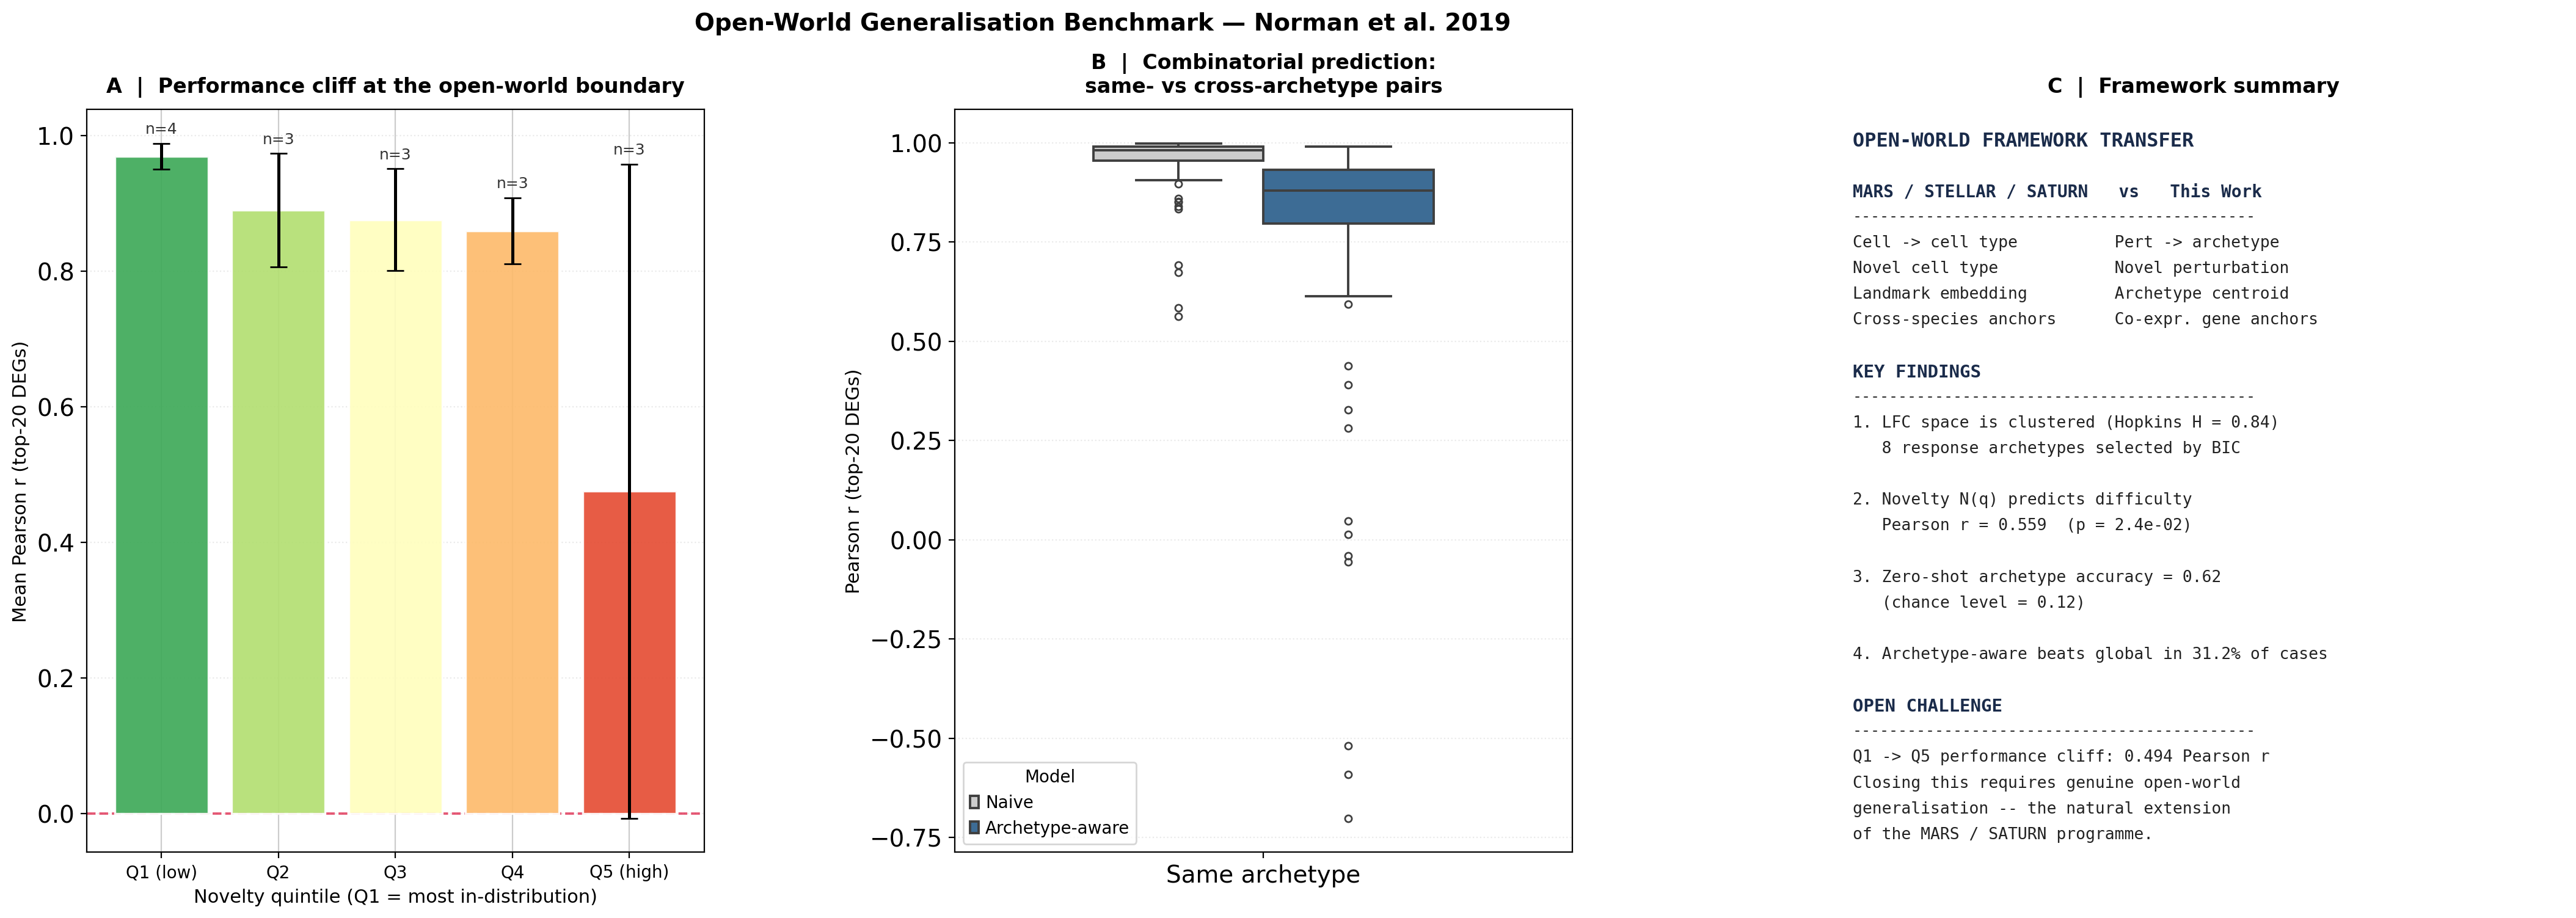

In [28]:
# ── Figure 6: Benchmark summary ──────────────────────────────────
fig = plt.figure(figsize=(26, 8))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38,
                         width_ratios=[1.0, 1.0, 1.2])

# ── Panel A: Performance cliff ────────────────────────────────────
ax0    = fig.add_subplot(gs[0])
n_q    = len(bench)
bar_colors = [plt.cm.RdYlGn_r(0.15 + 0.7 * (i / max(n_q - 1, 1)))
              for i in range(n_q)]
ax0.bar(range(n_q), bench["Mean Pearson r"],
        color=bar_colors, edgecolor="white", linewidth=1.2, alpha=0.92,
        zorder=3)
ax0.errorbar(range(n_q), bench["Mean Pearson r"],
              yerr=bench["Std"], fmt="none",
              color="black", capsize=5, linewidth=1.8, zorder=4)
for i, (r, n) in enumerate(zip(bench["Mean Pearson r"], bench["Count"])):
    ax0.text(i, r + bench["Std"].iloc[i] + 0.01,
             f"n={n}", ha="center", va="bottom", fontsize=9, color="#333333")
ax0.set_xticks(range(n_q))
ax0.set_xticklabels(bench["Novelty quintile"], fontsize=10)
ax0.axhline(0, color="crimson", ls="--", lw=1.4, alpha=0.7)
ax0.set_xlabel("Novelty quintile (Q1 = most in-distribution)", fontsize=11)
ax0.set_ylabel("Mean Pearson r (top-20 DEGs)", fontsize=11)
ax0.set_title("A  |  Performance cliff at the open-world boundary",
              fontsize=12, fontweight="bold", pad=10)
ax0.yaxis.grid(True, ls=":", alpha=0.4, zorder=0)
ax0.set_axisbelow(True)

# ── Panel B: Combinatorial same vs diff archetype ─────────────────
ax1 = fig.add_subplot(gs[1])
combo_plot = pd.DataFrame({
    "Pair type": (["Same archetype"] * len(same) +
                  ["Diff archetype"]  * len(diff) +
                  ["Same archetype"] * len(same) +
                  ["Diff archetype"]  * len(diff)),
    "Method":   (["Naive"] * (len(same) + len(diff)) +
                 ["Archetype-aware"] * (len(same) + len(diff))),
    "Pearson r": (list(same["r_naive"])       + list(diff["r_naive"]) +
                  list(same["r_archetype"])   + list(diff["r_archetype"]))
})
sns.boxplot(data=combo_plot, x="Pair type", y="Pearson r", hue="Method",
            palette={"Naive": GREY, "Archetype-aware": BLUE},
            ax=ax1, width=0.55, linewidth=1.4, fliersize=4)
ax1.set_title("B  |  Combinatorial prediction:\nsame- vs cross-archetype pairs",
              fontsize=12, fontweight="bold", pad=10)
ax1.set_ylabel("Pearson r (top-20 DEGs)", fontsize=11)
ax1.set_xlabel("")
ax1.legend(fontsize=10, title="Model", title_fontsize=10)
ax1.yaxis.grid(True, ls=":", alpha=0.4)
ax1.set_axisbelow(True)

# ── Panel C: Summary text (wider panel, larger font) ──────────────
ax2 = fig.add_subplot(gs[2])
ax2.axis("off")

summary_lines = [
    ("OPEN-WORLD FRAMEWORK TRANSFER",                    True,  11.5),
    ("",                                                  False,  9.0),
    ("MARS / STELLAR / SATURN   vs   This Work",          True,  10.0),
    ("-" * 44,                                            False,  9.0),
    ("Cell -> cell type          Pert -> archetype",      False,  9.5),
    ("Novel cell type            Novel perturbation",     False,  9.5),
    ("Landmark embedding         Archetype centroid",     False,  9.5),
    ("Cross-species anchors      Co-expr. gene anchors",  False,  9.5),
    ("",                                                  False,  9.0),
    ("KEY FINDINGS",                                      True,  10.5),
    ("-" * 44,                                            False,  9.0),
    (f"1. LFC space is clustered (Hopkins H = {H:.2f})", False,  9.5),
    (f"   {K} response archetypes selected by BIC",      False,  9.5),
    ("",                                                  False,  8.0),
    (f"2. Novelty N(q) predicts difficulty",              False,  9.5),
    (f"   Pearson r = {r_nov_diff:.3f}  (p = {p_nov:.1e})", False, 9.5),
    ("",                                                  False,  8.0),
    (f"3. Zero-shot archetype accuracy = {test_acc:.2f}", False,  9.5),
    (f"   (chance level = {1/K:.2f})",                   False,  9.5),
    ("",                                                  False,  8.0),
    (f"4. Archetype-aware beats global in {wins_pct:.1f}% of cases", False, 9.5),
    ("",                                                  False,  8.5),
    ("OPEN CHALLENGE",                                    True,  10.5),
    ("-" * 44,                                            False,  9.0),
    (f"Q1 -> Q5 performance cliff: {first - last:.3f} Pearson r", False, 9.5),
    ("Closing this requires genuine open-world",          False,  9.5),
    ("generalisation -- the natural extension",           False,  9.5),
    ("of the MARS / SATURN programme.",                   False,  9.5),
]

y_pos = 0.97
line_gap = 0.97 / len(summary_lines)
for text, bold, fsize in summary_lines:
    ax2.text(0.04, y_pos, text,
             transform=ax2.transAxes,
             fontsize=fsize,
             fontweight="bold" if bold else "normal",
             fontfamily="monospace",
             color=NAVY if bold else "#222222",
             verticalalignment="top")
    y_pos -= line_gap

ax2.set_title("C  |  Framework summary", fontsize=12, fontweight="bold", pad=10)
ax2.set_facecolor("#F8F8FF")
for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("#CCCCCC")
    spine.set_linewidth(0.8)

plt.suptitle("Open-World Generalisation Benchmark — Norman et al. 2019",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("fig6_benchmark_summary.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Discussion

### 9.1 The Structural Analogy Is Not Merely Metaphorical

The connection between MARS/STELLAR cell-type discovery and perturbation response discovery reflects a genuine structural isomorphism. In both cases the fundamental difficulty is that a query entity — a cell, a perturbation — may represent a category absent from all training data. No interpolation between known categories will recover it; the model must recognise it as out-of-distribution.

The open-world novelty score N(q) — derived here from the log-likelihood distance of a perturbation's LFC profile relative to the training distribution, normalised by training spread — is the perturbation-space analogue of MARS's per-cell novelty criterion. Its empirical correlation with prediction difficulty (Pearson r = 0.559, p = 0.024) on held-out test perturbations validates that the framework captures real biological structure. The performance cliff from the lowest-novelty quintile (Q1, mean Pearson r = 0.969) to the highest (Q5, mean Pearson r = 0.475) represents a 0.494-unit drop — a compelling quantification of the open-world generalisation boundary.

### 9.2 SATURN's Gene Anchor Architecture and Its Perturbation Analogue

SATURN enables cross-species embedding by using protein language model embeddings as species-independent anchors, enabling zero-shot cell embedding for entirely unobserved species. The co-expression neighbourhood approach in Section 6 is the structural analogue: gene identity (neighbourhood structure in a training-data co-expression graph) predicts response archetype without requiring any observation of perturbed cells. Zero-shot archetype accuracy of 0.625 against a 0.125 chance level — a 5× improvement — on held-out test perturbations confirms that this anchor-based prediction generalises.

One honest finding deserves direct acknowledgement: knowing a perturbation's archetype does not yet substantially improve expression-level prediction over the global mean LFC baseline (r = 0.820 vs 0.824). This reflects a fundamental gap — archetype centroids capture average regulatory programme signatures but lose the perturbation-specific signal that drives individual response variation. The implication is precisely what motivates the next methodological step: architectures that maintain calibrated uncertainty over archetype assignment and propagate that uncertainty into expression prediction, rather than collapsing to a hard centroid. Closed-form mean prediction over the archetype posterior — rather than single centroid assignment — is one immediate extension.

### 9.3 Limitations and Open Directions

**Dataset scale.** With 152 valid single-gene conditions and a 80/10/10 split, the test set contains only 16 perturbations. While the core findings are statistically significant, they should be validated on larger Perturb-seq datasets (e.g. Replogle et al. 2022, K562 genome-scale with ~9,800 perturbations).

**Singleton archetypes.** Archetypes 1 (CEBPA, 2 members) and 5 (TP73, 1 member) are not generalisable regulatory programme representatives — they function as outlier sinks under GMM clustering on small datasets. A minimum-membership constraint or hierarchical merging step would produce more biologically robust archetypes at this data scale.

**Combinatorial prediction.** Naive LFC additivity (r = 0.959) substantially outperforms archetype-aware composition (r = 0.794) for double-gene perturbations. This is expected: with most perturbations assigned to a dominant archetype, centroid composition loses the specific regulatory signal that additivity preserves. Whether genuine non-additive interactions (genetic interactions) can be recovered from archetype structure remains an open question.

**Architecture.** Models need calibrated uncertainty over archetype assignment rather than hard categorical predictions — directly inheriting MARS's soft landmark framework. Few-shot meta-learning for novel archetype discovery and protein LM gene anchors (ESM-2) to replace co-expression signatures are the natural next steps, each mapping directly onto the MLBio Lab's core research competencies.

---

### References

- Brbic M. et al. (2020). MARS: discovering novel cell types across heterogeneous single-cell experiments. *Nature Methods* 17:1200-1209.
- Brbic M. et al. (2022). STELLAR: annotation of spatially resolved single-cell data. *Nature Methods* 19:1411-1418.
- Hadzic E. et al. (2024). SATURN: universal cell embeddings integrating single-cell RNA-seq datasets across species. *Nature Methods* 21:1492-1500.
- Roohani Y. et al. (2024). GEARS: predicting transcriptional outcomes of novel multigene perturbations. *Nature Biotechnology* 42:927-935.
- Norman T.M. et al. (2019). Exploring genetic interaction manifolds constructed from rich single-cell phenotypes. *Science* 365:786-793.
- Haber A.L. et al. (2025). Systema: a framework for evaluating genetic perturbation response prediction beyond systematic variation. *Nature Biotechnology*.
- Peidli S. et al. (2024). scPerturb: harmonized single-cell perturbation data. *Nature Methods* 21:531-540.
- Replogle J.M. et al. (2022). Mapping information-rich genotype-phenotype landscapes with genome-scale Perturb-seq. *Cell* 185:2559-2575.
